
### This DataFrame contains 2008 Olympic medalists, each row represents an athlete.
 - There are 72 columns that contain gender and sport together indicatings what tier of medal was won (Gold,Silver, Bronze). 

### Tidy Data Principle Violated: 
Each variable should form a column: Initially he variables Gender and Sport are embedded in the column names rather than in their own separate columns. This is why we have several empty cells since each indiviudal plays specific sports and won a medal in only that specific sport. In a tidy format, each row should represent exactly one medal win.


In [126]:
# Data handling
import pandas as pd  
# Import 2008 Olypics dataset from a CSV file into a pandas DataFrame.
df = pd.read_csv('olympics_08_medalists.csv')
print(df.head())

# Plotting library for statistical data visualization          
import seaborn as sns     

# Plotting library for custom graphs 
import matplotlib.pyplot as plt      


       medalist_name male_archery female_archery male_athletics  \
0    Aaron Armstrong          NaN            NaN           gold   
1      Aaron Peirsol          NaN            NaN            NaN   
2   Abdullo Tangriev          NaN            NaN            NaN   
3  Abeer Abdelrahman          NaN            NaN            NaN   
4            Abhinav          NaN            NaN            NaN   

  female_athletics male_badminton female_badminton male_baseball  \
0              NaN            NaN              NaN           NaN   
1              NaN            NaN              NaN           NaN   
2              NaN            NaN              NaN           NaN   
3              NaN            NaN              NaN           NaN   
4              NaN            NaN              NaN           NaN   

  male_basketball female_basketball  ... female_beach volleyball  \
0             NaN               NaN  ...                     NaN   
1             NaN               NaN  ...            

In [127]:
#show summary stats
df.describe()

,medalist_name,male_archery,female_archery,male_athletics,female_athletics,male_badminton,female_badminton,male_baseball,male_basketball,female_basketball,...,female_beach volleyball,male_volleyball,female_volleyball,male_water polo,female_water polo,male_weightlifting,female_weightlifting,male_freestyle wrestling,female_freestyle wrestling,male_greco-roman wrestling
count,1875,11,9,85,81,12,10,72,35,36,...,6,36,36,39,39,24,21,28,16,27
unique,1875,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
top,Aaron Armstrong,bronze,bronze,silver,silver,silver,silver,silver,bronze,bronze,...,gold,bronze,gold,silver,gold,gold,bronze,bronze,bronze,bronze
freq,1,4,4,31,28,4,4,24,12,12,...,2,12,12,13,13,8,7,14,8,13


In [128]:
# Compute the sum of missing values per column and display the result.
df.isnull().sum()

medalist_name                    0
male_archery                  1864
female_archery                1866
male_athletics                1790
female_athletics              1794
                              ... 
male_weightlifting            1851
female_weightlifting          1854
male_freestyle wrestling      1847
female_freestyle wrestling    1859
male_greco-roman wrestling    1848
Length: 71, dtype: int64

In [129]:
# Melt the DataFrame
df_melted = pd.melt(df,
        id_vars = ["medalist_name"]  ,
        var_name = "Gender_Sport",
        value_name = "Medal" ,
        )
print(df_melted)


            medalist_name                Gender_Sport Medal
0         Aaron Armstrong                male_archery   NaN
1           Aaron Peirsol                male_archery   NaN
2        Abdullo Tangriev                male_archery   NaN
3       Abeer Abdelrahman                male_archery   NaN
4                 Abhinav                male_archery   NaN
...                   ...                         ...   ...
131245        Éver Banega  male_greco-roman wrestling   NaN
131246  Ólafur Stefánsson  male_greco-roman wrestling   NaN
131247      Óscar Brayson  male_greco-roman wrestling   NaN
131248   Łukasz Pawłowski  male_greco-roman wrestling   NaN
131249        Živko Gocić  male_greco-roman wrestling   NaN

[131250 rows x 3 columns]


In [130]:
# Remove empty rows(only NaN in Medal column)
df_melted_tidy = df_melted.dropna()
# Reset index after empty rows have been dropped
df_melted_tidy= df_melted_tidy.reset_index(drop = True)

print(df_melted_tidy)

            medalist_name                Gender_Sport   Medal
0            Bair Badënov                male_archery  bronze
1           Ilario Di Buò                male_archery  silver
2            Im Dong-hyun                male_archery    gold
3               Jiang Lin                male_archery  bronze
4          Lee Chang-hwan                male_archery    gold
...                   ...                         ...     ...
1870        Steeve Guénot  male_greco-roman wrestling    gold
1871  Yannick Szczepaniak  male_greco-roman wrestling  bronze
1872       Yavor Yanakiev  male_greco-roman wrestling  bronze
1873      Yury Patrikeyev  male_greco-roman wrestling  bronze
1874         Zoltán Fodor  male_greco-roman wrestling  silver

[1875 rows x 3 columns]


In [163]:
#Split column of "Gender_Sport" since they contain two variables using str.split()
new_columns = (df_melted_tidy.
  Gender_Sport.str.split("_", expand = True).
  rename(columns = {0:"Gender", 1:"Sport"})
  )
print(new_columns)
# drop the combined variable column (Gender_Sport) and insert new columns into the data frame
df_Final_Tidy = pd.concat([df_melted_tidy.drop(columns = 'Gender_Sport'), new_columns], axis = 1)

     Gender                  Sport
0      male                archery
1      male                archery
2      male                archery
3      male                archery
4      male                archery
...     ...                    ...
1870   male  greco-roman wrestling
1871   male  greco-roman wrestling
1872   male  greco-roman wrestling
1873   male  greco-roman wrestling
1874   male  greco-roman wrestling

[1875 rows x 2 columns]


In [164]:
print(df_Final_Tidy)

            medalist_name   Medal Gender                  Sport
0            Bair Badënov  bronze   male                archery
1           Ilario Di Buò  silver   male                archery
2            Im Dong-hyun    gold   male                archery
3               Jiang Lin  bronze   male                archery
4          Lee Chang-hwan    gold   male                archery
...                   ...     ...    ...                    ...
1870        Steeve Guénot    gold   male  greco-roman wrestling
1871  Yannick Szczepaniak  bronze   male  greco-roman wrestling
1872       Yavor Yanakiev  bronze   male  greco-roman wrestling
1873      Yury Patrikeyev  bronze   male  greco-roman wrestling
1874         Zoltán Fodor  silver   male  greco-roman wrestling

[1875 rows x 4 columns]


### Outcome:
- The resulting tidy DataFrame now has 4 columns with each row containing information of medal awarded, gender and sport. 
- The variables of sport and gender now are each in their own column.
- This structure makes it easier to analyze trends, perform statistical tests, or create visualizations (e.g., count plot of medals by gender).

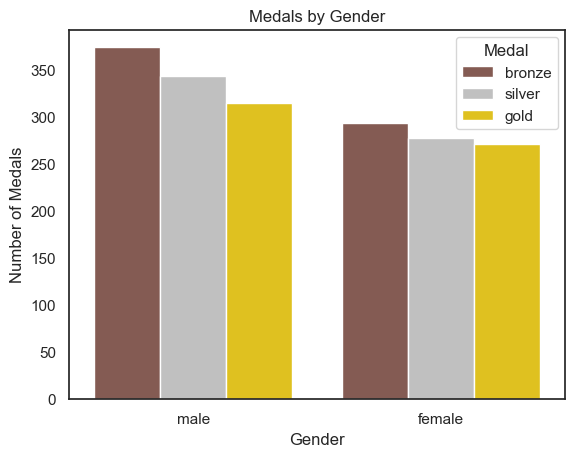

In [171]:
# Change visualization colors for aesthetic presentation of graph
palette = {
    'bronze': 'tab:brown',
    'silver': 'silver',
    'gold': 'gold',
}
# Create a visualization with new tidy data 
sns.countplot( x = 'Gender', hue = 'Medal',  data = df_Final_Tidy, palette=palette, )
# Label Title and axis for visual presentation
plt.title("Medals by Gender")
plt.ylabel ("Number of Medals")
plt.show()

